<h1 align="left">AlphaGenome Tutorial</h1>

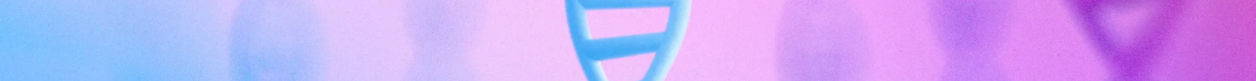

AlphaGenome takes a DNA sequence as input and predicts multiple genomic tracks simultaneously.

# Part 1: Model Exploration

> **Nikita Vaulin**<br>
> PhD-student, Adameyko lab <br>
> tg: @nvaulin<br>
> nikita.vaulin@meduniwien.ac.at

### Contents
- [1.1. Loading libraries](#11-loading-libraries)
- [1.2. Getting the model with API key](#12-getting-the-model-with-api-key)
- [1.3. Metadata: exploring output tracks](#13-metadata-exploring-output-tracks)


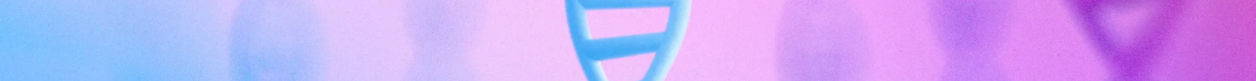

## 1.1. Loading libraries

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import alphagenome
from alphagenome.models import dna_client
print(alphagenome.__version__)

0.6.1


/home/nikita/miniforge3/envs/alphagenome-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2. Getting the model with API key

In [3]:
key = ! cat /home/nikita/tools/alphagenome_key.txt
key = key[0]

In [4]:
dna_model = dna_client.create(key)
print(dna_model)
print()
print(*[attr for attr in dir(dna_model) if not attr.startswith('_')], sep='\n')


output_metadata
predict_interval
predict_intervals
predict_sequence
predict_sequences
predict_variant
predict_variants
score_interval
score_intervals
score_ism_variants
score_variant
score_variants


## 1.3. Metadata: exploring output tracks

The model supports two organisms:
- `*Homo sapience* (9606)
- *Mus musculus* (10090)

... and 11 diferent modalities.

A complete registry of the tracks model is able to predict can be found in `dna_model.output_metadata()` object.

In [5]:
list(dna_client.Organism)

[<Organism.HOMO_SAPIENS: 9606>, <Organism.MUS_MUSCULUS: 10090>]

In [6]:
list(dna_client.OutputType)

[ATAC,
 CAGE,
 DNASE,
 RNA_SEQ,
 CHIP_HISTONE,
 CHIP_TF,
 SPLICE_SITES,
 SPLICE_SITE_USAGE,
 SPLICE_JUNCTIONS,
 CONTACT_MAPS,
 PROCAP]

In [7]:
output_metadata = dna_model.output_metadata(
                            organism = dna_client.Organism.HOMO_SAPIENS
)

With `output_metadata` you can easily explore all relecant information about the tracks:

*   `name`: Name of the track. Example: `CL:0000047 polyA plus RNA-seq`.
*   `strand` Strand of the track, either positive (`+`), negative (`-`), or
    unstranded (`.`).
*   `ontology_curie`: A string ID representing the ontology term corresponding
    to the biosample. Example: `CL:0000100`.
*   `biosample_name`: Plain text description of the biosample. Example: `motor
    neuron`.

> 💡 More information about the tracks can be found here: [Model output metadata](https://www.alphagenomedocs.com/exploring_model_metadata.html)

In [8]:
output_metadata = output_metadata.concatenate()
    
output_metadata.head(3)

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean,output_type,gtex_tissue,histone_mark,transcription_factor
0,CL:0000084 ATAC-seq,.,ATAC-seq,CL:0000084,T-cell,primary_cell,adult,encode,paired,False,0.739741,OutputType.ATAC,NaN,NaN,NaN
1,CL:0000100 ATAC-seq,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.273136,OutputType.ATAC,NaN,NaN,NaN
2,CL:0000236 ATAC-seq,.,ATAC-seq,CL:0000236,B cell,primary_cell,adult,encode,paired,False,4.700081,OutputType.ATAC,NaN,NaN,NaN


### Cell Ontology & CURIEs

Each track has its own unique ID - *ontology_curie*


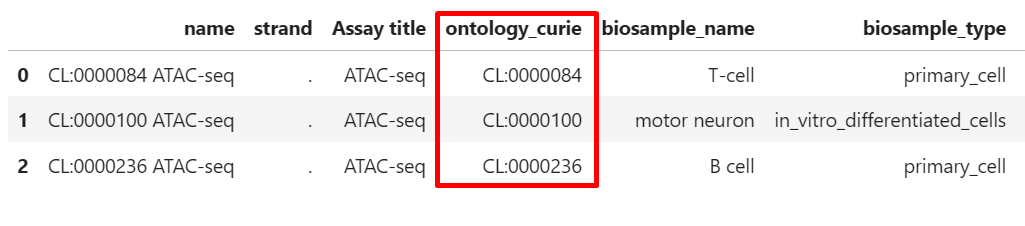

**Cell Ontology (CL)** is a standardized hierarchical vocabulary for cell types,
maintained by the [OBO Foundry](https://obofoundry.org/). Every cell type gets a unique numeric ID, e.g.:


<table style="margin:0">
  <tr><th>CURIE</th><th>Cell type</th></tr>
  <tr><td><code>CL:0000084</code></td><td>T cell</td></tr>
  <tr><td><code>CL:0000100</code></td><td>motor neuron</td></tr>
  <tr><td><code>CL:0000236</code></td><td>B cell</td></tr>
</table>
</br>

**CURIE** (*Compact URI*) is just a shorthand notation for a full URI:
`CL:0000084` → http://purl.obolibrary.org/obo/CL_0000084

Using CURIEs instead of free-text cell names ensures tracks are
unambiguously identified and interoperable across datasets and databases.

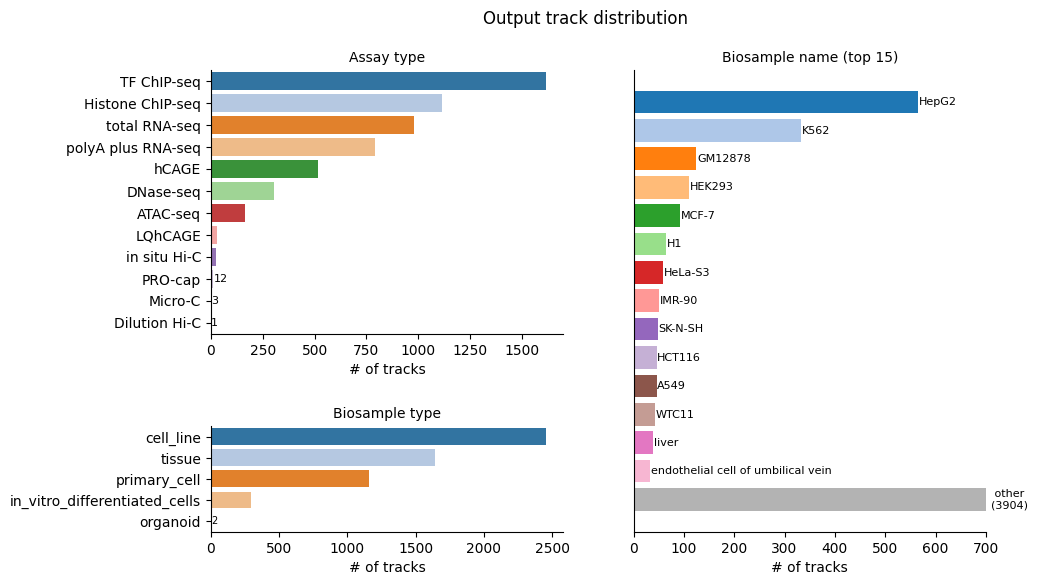

In [9]:
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2, height_ratios=(2.5,1), wspace=0.2, hspace=0.5)

fig.suptitle("Output track distribution", fontsize=12)

# top-left: assay
ax = fig.add_subplot(gs[0, 0])
counts = output_metadata["Assay title"].value_counts()
sns.barplot(x=counts.values, y=counts.index, ax=ax, palette=plt.cm.tab20(range(len(counts))))
ax.set_title("Assay type", fontsize=10)
ax.set_xlabel("# of tracks", fontsize=10)
ax.set_ylabel("")
for i, val in enumerate(counts.values):
    if val < 20:
        ax.text(val + 0.2, i, str(val), va="center", fontsize=8)

# bottom-left: biosample type
ax = fig.add_subplot(gs[1, 0])
counts = output_metadata["biosample_type"].value_counts()
sns.barplot(x=counts.values, y=counts.index, ax=ax, palette=plt.cm.tab20(range(len(counts))))
ax.set_title("Biosample type", fontsize=10)
ax.set_xlabel("# of tracks", fontsize=10)
ax.set_ylabel("")
for i, val in enumerate(counts.values):
    if val < 10:
        ax.text(val + 0.2, i, str(val), va="center", fontsize=7)

# right: biosample name, spans both rows
ax = fig.add_subplot(gs[:, 1])
name_counts = output_metadata["biosample_name"].value_counts()
top14 = name_counts.head(14)
other_count = name_counts.iloc[14:].sum()
counts = pd.concat([top14, pd.Series({"other": other_count})])
colors = [*plt.cm.tab20(range(14)), (0.7, 0.7, 0.7, 1.0)]
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1])
ax.set_title("Biosample name (top 15)", fontsize=10)
ax.set_xlabel("# of tracks", fontsize=10)
ax.set_yticks([])
ax.set_xlim(0, 700)
for bar, (name, val) in zip(bars[::-1], counts.items()):
    label = f" other\n({val})" if name == "other" else name
    t_x = ax.get_xlim()[1]+10 if name == "other" else bar.get_width() + 1
    ax.text(t_x, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=8)

sns.despine()
plt.show()

Navigating `output_metadata` much easier with any interactive table tool. For instance, you can try [itables](https://mwouts.github.io/itables/quick_start.html)!

In [10]:
import itables

itables.show(output_metadata, maxBytes=0, style="table-layout:auto;width:80%;")

Loading ITables v2.7.3 from the internet... (need help?)
